<a href="https://colab.research.google.com/github/asmitaagarwal756/Earthquake-Prediction/blob/main/K_Means_clustering_FAIECE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

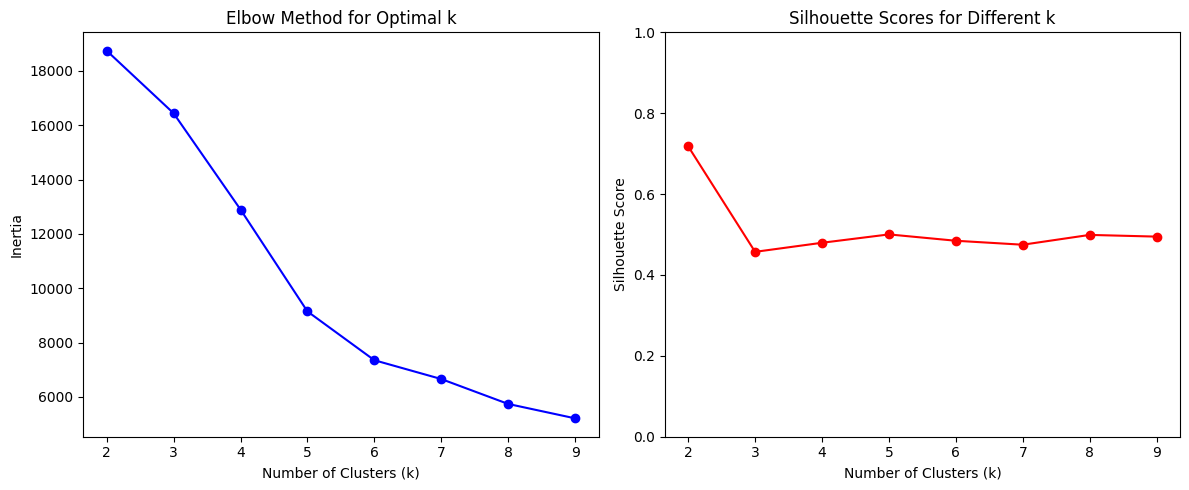

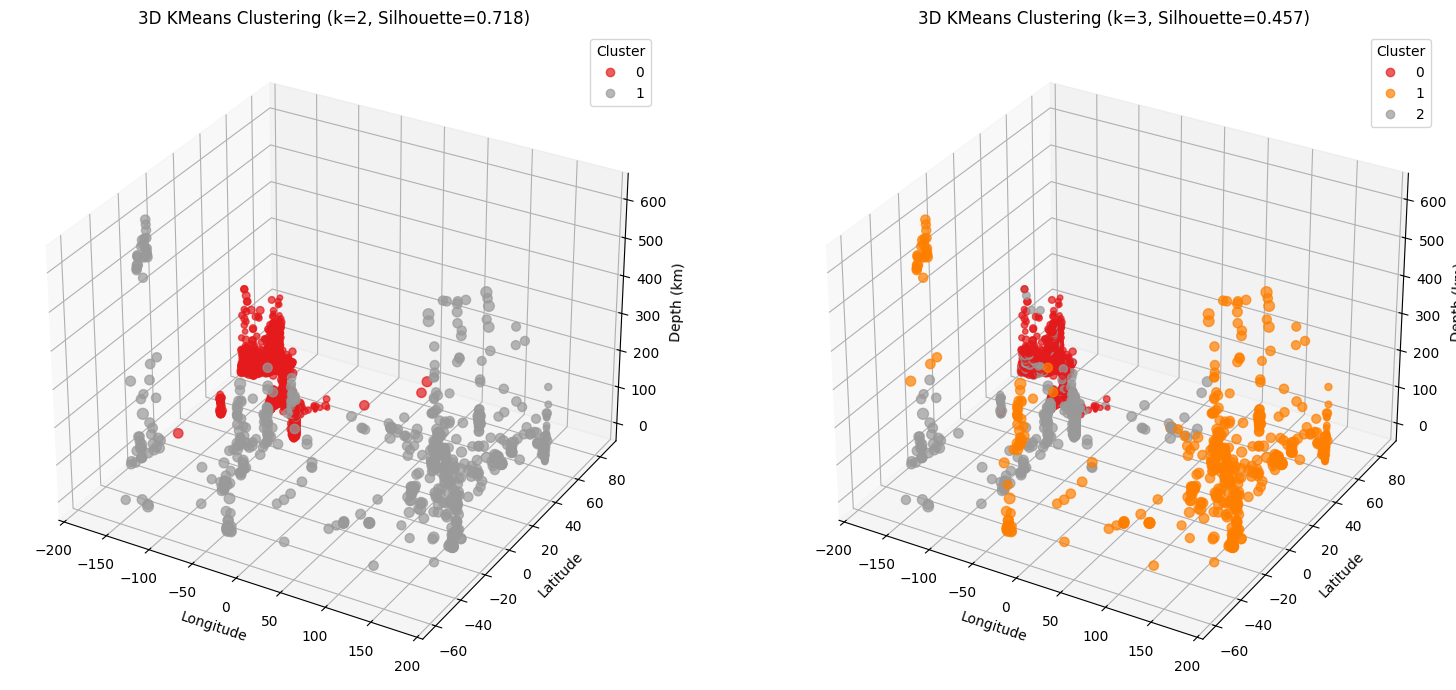

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

df = pd.read_csv("earthquakes.csv")

# 2. Drop irrelevant columns
drop_cols = [
    'time.hour','time.minute','time.month','time.second',
    'time.year','time.day','time.epoch','time.full','location.name'
]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# 3. Encode categorical columns
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# 4. Select features (including depth & magnitude)
features = [
    "impact.magnitude","location.depth",
    "location.latitude","location.longitude"
]
X = df[features]

# 5. Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 6. Elbow Method + Silhouette Scores
inertias = []
sil_scores = []
K_range = range(2,10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

# Plot Elbow Method
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(K_range, inertias, 'bo-')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")

# Plot Silhouette Scores
plt.subplot(1,2,2)
plt.plot(K_range, sil_scores, 'ro-')
plt.title("Silhouette Scores for Different k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.ylim(0,1)

plt.tight_layout()
plt.show()

# 7. Side-by-side 3D plots for k=2 vs k=3
fig = plt.figure(figsize=(16,7))

for idx, k in enumerate([2,3]):
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, clusters)

    ax = fig.add_subplot(1,2,idx+1, projection='3d')
    scatter = ax.scatter(
        df["location.longitude"],
        df["location.latitude"],
        df["location.depth"],
        c=clusters, cmap="Set1", s=df["impact.magnitude"]*10, alpha=0.7
    )
    ax.set_title(f"3D KMeans Clustering (k={k}, Silhouette={sil:.3f})")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_zlabel("Depth (km)")
    ax.legend(*scatter.legend_elements(), title="Cluster")

plt.tight_layout()
plt.show()